# Chapter 4: Introduction to Dynamic Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 4.1-4.3: steady states, continuous-time dynamical systems, and discrete-time dynamical systems.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 4.1 Steady-state analysis: competing trees

The model uses logistic self-limitation and bilinear competition:

\[
H'=r_1H-a_1H^2-b_1HS,\qquad
S'=r_2S-a_2S^2-b_2HS.
\]

Equilibria are obtained from the balance equations \(H'=S'=0\).


In [2]:
H, S = sp.symbols("H S", nonnegative=True, real=True)
r1, r2, a1, a2, b1, b2 = sp.symbols("r1 r2 a1 a2 b1 b2", positive=True, real=True)

fH = r1 * H - a1 * H**2 - b1 * H * S
fS = r2 * S - a2 * S**2 - b2 * H * S
interior = sp.solve([sp.factor(fH / H), sp.factor(fS / S)], (H, S), dict=True)[0]

print("Interior coexistence equilibrium:")
display(interior)
print("The other equilibria are (0,0), (r1/a1,0), and (0,r2/a2).")


Interior coexistence equilibrium:


{H: (a2*r1 - b1*r2)/(a1*a2 - b1*b2), S: (a1*r2 - b2*r1)/(a1*a2 - b1*b2)}

The other equilibria are (0,0), (r1/a1,0), and (0,r2/a2).


## 4.2 Dynamical systems: the whale model

Blue and fin whales follow logistic growth with a common competition term. The state is the current population pair; the vector field determines the future path.


In [3]:
from scipy.integrate import solve_ivp

alpha = 1e-7
K_blue, K_fin = 150_000.0, 400_000.0
r_blue, r_fin = 0.05, 0.08

def whale_rhs(time, state, alpha=alpha):
    blue, fin = state
    competition = alpha * blue * fin
    return np.array([
        r_blue * blue * (1 - blue / K_blue) - competition,
        r_fin * fin * (1 - fin / K_fin) - competition,
    ])

# Solve the two positive nullcline equations.
A = np.array([[r_blue / K_blue, alpha], [alpha, r_fin / K_fin]])
b = np.array([r_blue, r_fin])
coexistence = np.linalg.solve(A, b)
print("Coexistence equilibrium:", coexistence)
assert np.allclose(coexistence, [600_000 / 17, 6_500_000 / 17], rtol=1e-8)


Coexistence equilibrium: [ 35294.117647 382352.941176]


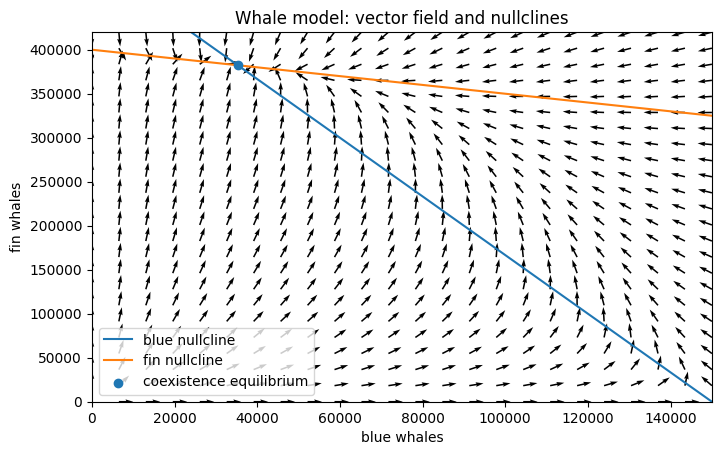

In [4]:
blue_grid = np.linspace(0, 150_000, 24)
fin_grid = np.linspace(0, 420_000, 24)
BG, FG = np.meshgrid(blue_grid, fin_grid)
DU = r_blue * BG * (1 - BG / K_blue) - alpha * BG * FG
DV = r_fin * FG * (1 - FG / K_fin) - alpha * BG * FG
speed = np.hypot(DU, DV)
DU_n = np.divide(DU, speed, out=np.zeros_like(DU), where=speed > 0)
DV_n = np.divide(DV, speed, out=np.zeros_like(DV), where=speed > 0)

plt.quiver(BG, FG, DU_n, DV_n, angles="xy")
blue_line = np.linspace(0, 150_000, 500)
fin_nullcline = r_blue * (1 - blue_line / K_blue) / alpha
plt.plot(blue_line, fin_nullcline, label="blue nullcline")
fin_line = np.linspace(0, 400_000, 500)
blue_nullcline = r_fin * (1 - fin_line / K_fin) / alpha
plt.plot(blue_nullcline, fin_line, label="fin nullcline")
plt.scatter([coexistence[0]], [coexistence[1]], zorder=3, label="coexistence equilibrium")
plt.xlim(0, 150_000)
plt.ylim(0, 420_000)
plt.xlabel("blue whales")
plt.ylabel("fin whales")
plt.title("Whale model: vector field and nullclines")
plt.legend()
plt.show()


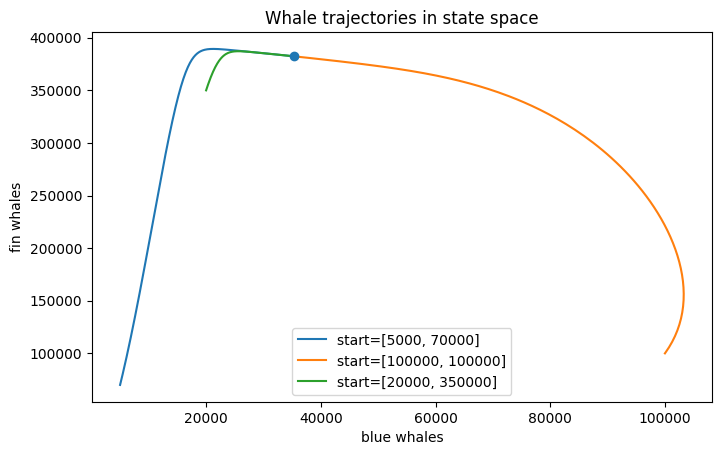

In [5]:
initial_states = [
    [5_000, 70_000],
    [100_000, 100_000],
    [20_000, 350_000],
]
for initial in initial_states:
    sol = solve_ivp(whale_rhs, (0, 800), initial, dense_output=False, rtol=1e-9, atol=1e-8, max_step=1.0)
    plt.plot(sol.y[0], sol.y[1], label=f"start={initial}")
plt.scatter([coexistence[0]], [coexistence[1]], zorder=3)
plt.xlabel("blue whales")
plt.ylabel("fin whales")
plt.title("Whale trajectories in state space")
plt.legend()
plt.show()


## 4.3 Discrete time and built-in delay

For the scalar model \(\Delta x=-\lambda x\), the iteration is

\[
x_{n+1}=(1-\lambda)x_n.
\]

The continuous analogue is stable for every \(\lambda>0\), but the discrete model is stable only when \(|1-\lambda|<1\). A time step is not decorative punctuation; it changes the dynamics.


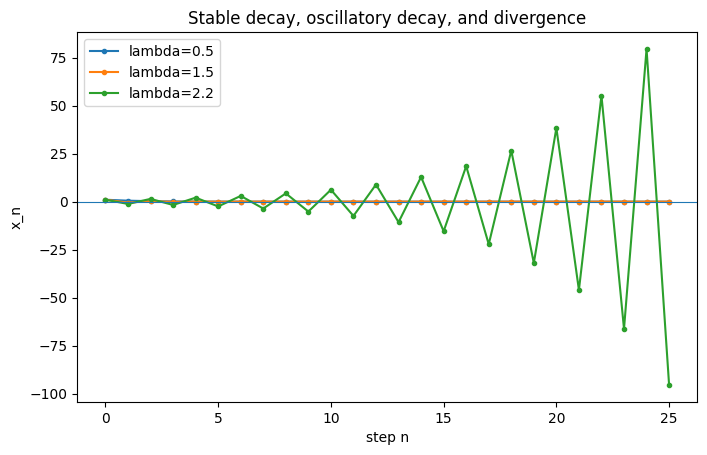

In [6]:
def scalar_discrete(lam, x0=1.0, steps=25):
    values = [float(x0)]
    for _ in range(steps):
        values.append((1 - lam) * values[-1])
    return np.array(values)

for lam in [0.5, 1.5, 2.2]:
    plt.plot(scalar_discrete(lam), marker="o", markersize=3, label=f"lambda={lam}")
plt.axhline(0, linewidth=0.8)
plt.xlabel("step n")
plt.ylabel("x_n")
plt.title("Stable decay, oscillatory decay, and divergence")
plt.legend()
plt.show()


### Docking-control state model

With a fixed control-adjustment time \(c\), waiting time \(w\), and gain \(k\), the state \((v_n,v_{n-1})\) evolves linearly.


Iteration matrix:
 [[ 0.8 -0.1]
 [ 1.   0. ]]
Eigenvalues: [0.644949 0.155051]


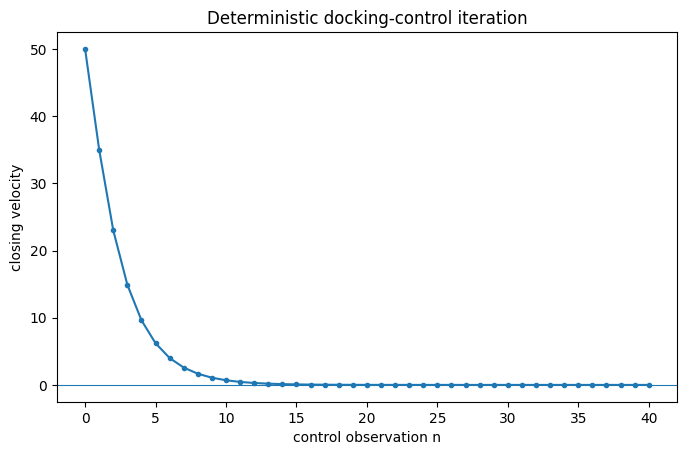

In [7]:
def docking_matrix(k, c=5.0, w=10.0):
    return np.array([[1 - k * w, -k * c], [1.0, 0.0]])

def iterate_linear(matrix, initial, steps=40):
    states = [np.asarray(initial, dtype=float)]
    for _ in range(steps):
        states.append(matrix @ states[-1])
    return np.vstack(states)

M = docking_matrix(k=0.02)
docking_states = iterate_linear(M, [50.0, 50.0], steps=40)
print("Iteration matrix:\n", M)
print("Eigenvalues:", np.linalg.eigvals(M))

plt.plot(docking_states[:, 0], marker="o", markersize=3)
plt.axhline(0, linewidth=0.8)
plt.xlabel("control observation n")
plt.ylabel("closing velocity")
plt.title("Deterministic docking-control iteration")
plt.show()


## Chapter checkpoint

Steady-state equations locate candidate long-run states, while vector fields and trajectories answer whether the system approaches them. Discrete-time models can overshoot or destabilize an equilibrium even when the corresponding continuous system is stable.
